In [21]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm


In [22]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [23]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [24]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [25]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 271.11it/s]


In [26]:
batch_size = 64
beta = 1e-1
learning_rate = 1e-3
num_epochs = 120
channels = 1
latent_dim = 64
# num_embeddings = 256 
LOG_EVERY = 10


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [28]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [29]:
event_train = events_train[:SELECTED_EVENTS][0]

In [30]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [31]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [32]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    
    # KL_divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [33]:
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1),  
            nn.LeakyReLU(),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1),
            nn.LeakyReLU(),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(hidden_channels * 2)
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        self.z_log_var = torch.clamp(z_log_var, min=-4, max=1)
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [34]:
model = VAE(
    hidden_channels=32, 
    kernel_size = 4
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/120: 100%|██████████| 248/248 [00:00<00:00, 593.26it/s, Loss=337]   


Epoch [1/120] Average Loss: 1069.2822
Before compression
Before: (64, 8, 8)


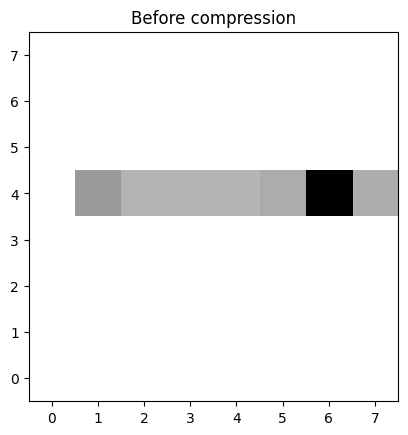

mu: mean=-0.0155, std=0.2764 | logvar: mean=-0.0504, std=0.0366
Loss statistics:
recon=291.3882, kl=453.9084, beta_kl=45.3908
After: (1, 8, 8)
After compression


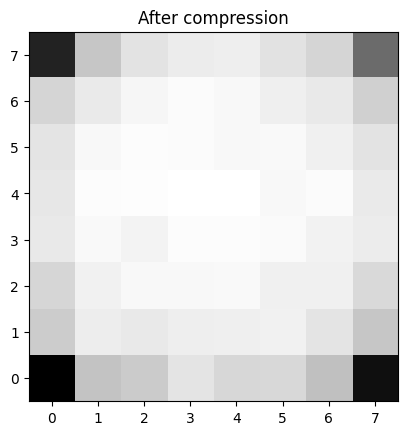

Epoch 2/120: 100%|██████████| 248/248 [00:00<00:00, 627.89it/s, Loss=310]


Epoch [2/120] Average Loss: 431.3042


Epoch 3/120: 100%|██████████| 248/248 [00:00<00:00, 624.44it/s, Loss=310]


Epoch [3/120] Average Loss: 404.6114


Epoch 4/120: 100%|██████████| 248/248 [00:00<00:00, 621.53it/s, Loss=284]


...

Epoch [9/120] Average Loss: 297.6360


Epoch 10/120: 100%|██████████| 248/248 [00:00<00:00, 653.17it/s, Loss=205]


Epoch [10/120] Average Loss: 283.5131


Epoch 11/120: 100%|██████████| 248/248 [00:00<00:00, 613.46it/s, Loss=196]


Epoch [11/120] Average Loss: 274.2239
Before compression
Before: (64, 8, 8)


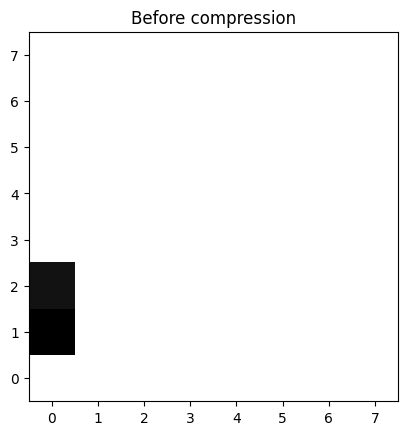

mu: mean=-0.0004, std=0.2281 | logvar: mean=-0.0660, std=0.1232
Loss statistics:
recon=163.2424, kl=325.3998, beta_kl=32.5400
After: (1, 8, 8)
After compression


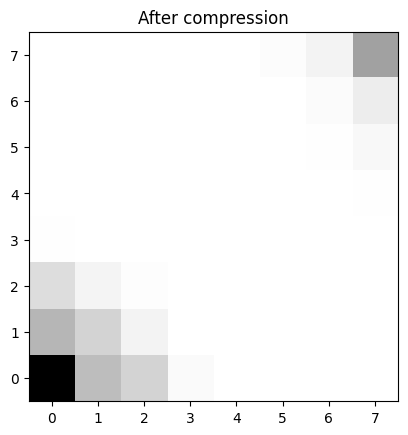

Epoch 12/120: 100%|██████████| 248/248 [00:00<00:00, 574.38it/s, Loss=191]


Epoch [12/120] Average Loss: 266.1892


Epoch 13/120: 100%|██████████| 248/248 [00:00<00:00, 603.98it/s, Loss=191]


Epoch [13/120] Average Loss: 258.2570


Epoch 14/120: 100%|██████████| 248/248 [00:00<00:00, 593.20it/s, Loss=186]


...

Epoch [19/120] Average Loss: 244.8791


Epoch 20/120: 100%|██████████| 248/248 [00:00<00:00, 625.61it/s, Loss=179]


Epoch [20/120] Average Loss: 241.9773


Epoch 21/120: 100%|██████████| 248/248 [00:00<00:00, 635.02it/s, Loss=177]


Epoch [21/120] Average Loss: 245.6562
Before compression
Before: (64, 8, 8)


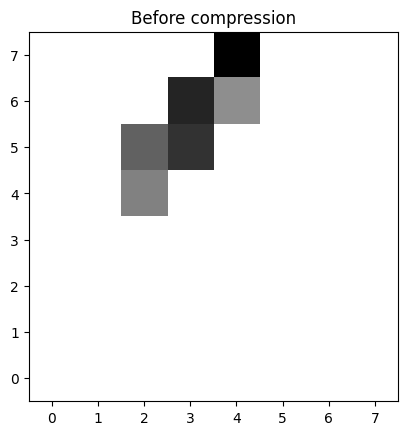

mu: mean=-0.0025, std=0.1911 | logvar: mean=-0.0590, std=0.2904
Loss statistics:
recon=146.1808, kl=311.6183, beta_kl=31.1618
After: (1, 8, 8)
After compression


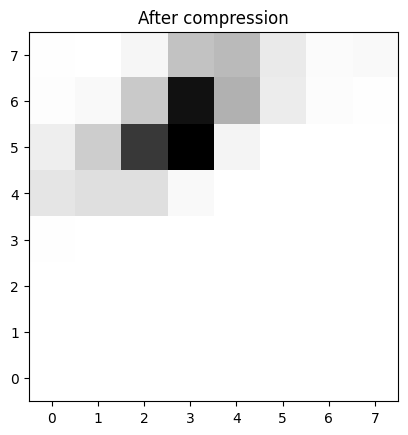

Epoch 22/120: 100%|██████████| 248/248 [00:00<00:00, 650.56it/s, Loss=176]


Epoch [22/120] Average Loss: 238.1519


Epoch 23/120: 100%|██████████| 248/248 [00:00<00:00, 625.97it/s, Loss=174]


Epoch [23/120] Average Loss: 237.3227


Epoch 24/120: 100%|██████████| 248/248 [00:00<00:00, 630.95it/s, Loss=235]


...

Epoch [29/120] Average Loss: 231.8080


Epoch 30/120: 100%|██████████| 248/248 [00:00<00:00, 642.29it/s, Loss=168]


Epoch [30/120] Average Loss: 233.5074


Epoch 31/120: 100%|██████████| 248/248 [00:00<00:00, 624.86it/s, Loss=176]


Epoch [31/120] Average Loss: 230.7427
Before compression
Before: (64, 8, 8)


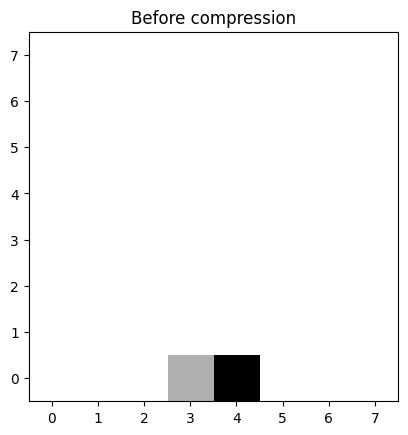

mu: mean=-0.0001, std=0.1647 | logvar: mean=-0.0451, std=0.3051
Loss statistics:
recon=143.2188, kl=327.3407, beta_kl=32.7341
After: (1, 8, 8)
After compression


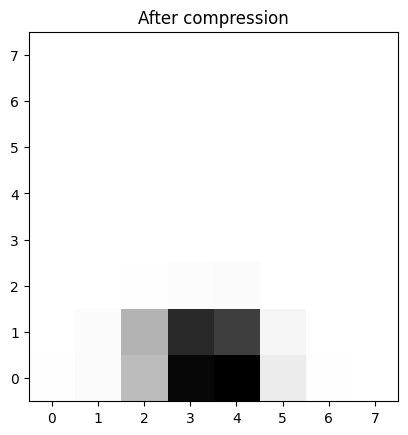

Epoch 32/120: 100%|██████████| 248/248 [00:00<00:00, 577.74it/s, Loss=165]


Epoch [32/120] Average Loss: 231.5640


Epoch 33/120: 100%|██████████| 248/248 [00:00<00:00, 567.55it/s, Loss=168]


Epoch [33/120] Average Loss: 232.4703


Epoch 34/120: 100%|██████████| 248/248 [00:00<00:00, 616.67it/s, Loss=163]


...

Epoch [39/120] Average Loss: 228.6930


Epoch 40/120: 100%|██████████| 248/248 [00:00<00:00, 629.85it/s, Loss=172]


Epoch [40/120] Average Loss: 226.1179


Epoch 41/120: 100%|██████████| 248/248 [00:00<00:00, 616.78it/s, Loss=163]


Epoch [41/120] Average Loss: 226.8811
Before compression
Before: (64, 8, 8)


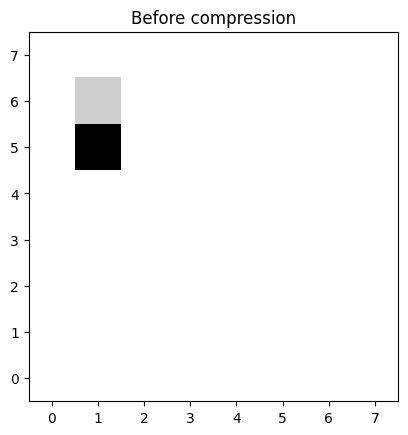

mu: mean=-0.0029, std=0.1935 | logvar: mean=-0.0637, std=0.3474
Loss statistics:
recon=129.5163, kl=334.6867, beta_kl=33.4687
After: (1, 8, 8)
After compression


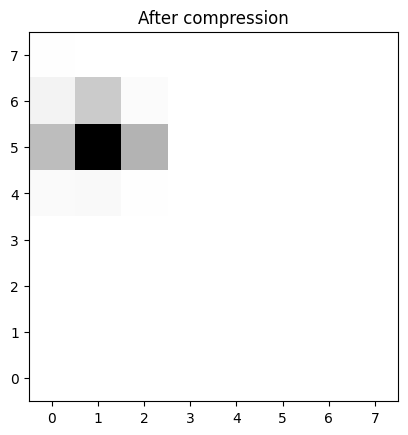

Epoch 42/120: 100%|██████████| 248/248 [00:00<00:00, 609.09it/s, Loss=167]


Epoch [42/120] Average Loss: 224.2470


Epoch 43/120: 100%|██████████| 248/248 [00:00<00:00, 626.46it/s, Loss=166]


Epoch [43/120] Average Loss: 225.7227


Epoch 44/120: 100%|██████████| 248/248 [00:00<00:00, 623.12it/s, Loss=164]


...

Epoch [49/120] Average Loss: 226.0934


Epoch 50/120: 100%|██████████| 248/248 [00:00<00:00, 560.80it/s, Loss=167]


Epoch [50/120] Average Loss: 225.4751


Epoch 51/120: 100%|██████████| 248/248 [00:00<00:00, 573.36it/s, Loss=166]


Epoch [51/120] Average Loss: 223.0041
Before compression
Before: (64, 8, 8)


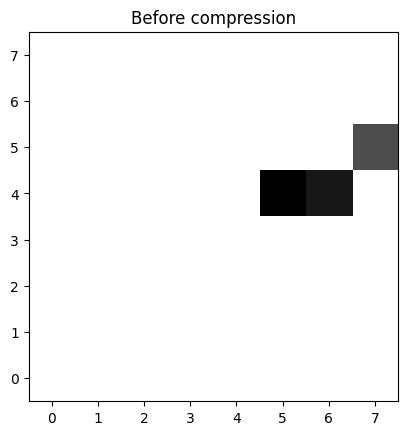

mu: mean=-0.0017, std=0.1807 | logvar: mean=-0.0584, std=0.3604
Loss statistics:
recon=131.7391, kl=342.9870, beta_kl=34.2987
After: (1, 8, 8)
After compression


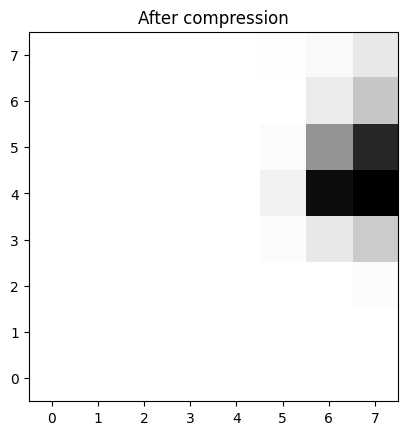

Epoch 52/120: 100%|██████████| 248/248 [00:00<00:00, 612.76it/s, Loss=166]


Epoch [52/120] Average Loss: 225.3215


Epoch 53/120: 100%|██████████| 248/248 [00:00<00:00, 629.93it/s, Loss=164]


Epoch [53/120] Average Loss: 223.4375


Epoch 54/120: 100%|██████████| 248/248 [00:00<00:00, 648.97it/s, Loss=165]


...

Epoch [59/120] Average Loss: 221.9331


Epoch 60/120: 100%|██████████| 248/248 [00:00<00:00, 661.67it/s, Loss=159]


Epoch [60/120] Average Loss: 222.6507


Epoch 61/120: 100%|██████████| 248/248 [00:00<00:00, 648.75it/s, Loss=164]


Epoch [61/120] Average Loss: 220.8068
Before compression
Before: (64, 8, 8)


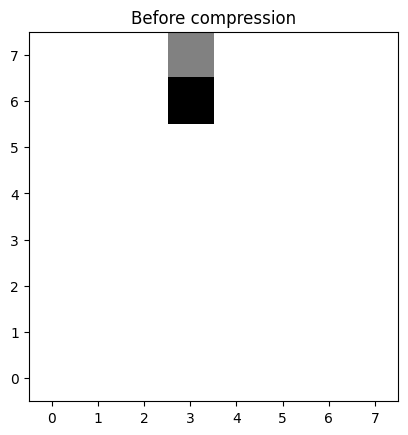

mu: mean=-0.0005, std=0.1692 | logvar: mean=-0.0540, std=0.3507
Loss statistics:
recon=129.1661, kl=348.9033, beta_kl=34.8903
After: (1, 8, 8)
After compression


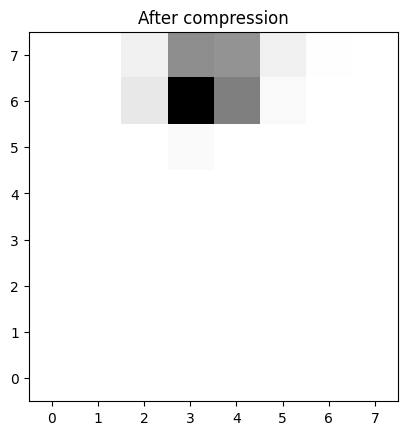

Epoch 62/120: 100%|██████████| 248/248 [00:00<00:00, 635.67it/s, Loss=158]


Epoch [62/120] Average Loss: 219.1717


Epoch 63/120: 100%|██████████| 248/248 [00:00<00:00, 636.19it/s, Loss=195]


Epoch [63/120] Average Loss: 223.1802


Epoch 64/120: 100%|██████████| 248/248 [00:00<00:00, 655.11it/s, Loss=160]


...

Epoch [69/120] Average Loss: 220.8594


Epoch 70/120: 100%|██████████| 248/248 [00:00<00:00, 614.20it/s, Loss=158]


Epoch [70/120] Average Loss: 218.2775


Epoch 71/120: 100%|██████████| 248/248 [00:00<00:00, 618.89it/s, Loss=192]


Epoch [71/120] Average Loss: 218.6141
Before compression
Before: (64, 8, 8)


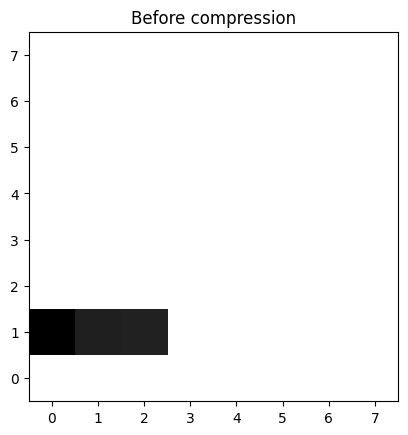

mu: mean=0.0000, std=0.1780 | logvar: mean=-0.0541, std=0.3586
Loss statistics:
recon=155.1841, kl=365.4693, beta_kl=36.5469
After: (1, 8, 8)
After compression


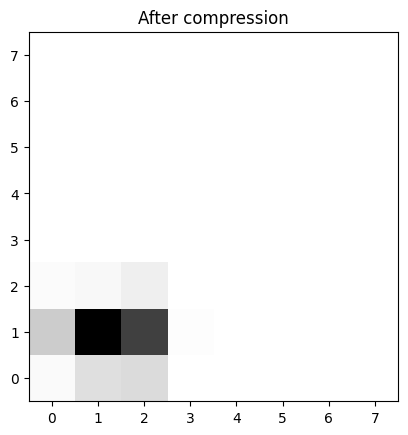

Epoch 72/120: 100%|██████████| 248/248 [00:00<00:00, 594.41it/s, Loss=159]


Epoch [72/120] Average Loss: 218.5384


Epoch 73/120: 100%|██████████| 248/248 [00:00<00:00, 622.14it/s, Loss=160]


Epoch [73/120] Average Loss: 220.5634


Epoch 74/120: 100%|██████████| 248/248 [00:00<00:00, 608.04it/s, Loss=159]


...

Epoch [79/120] Average Loss: 219.2476


Epoch 80/120: 100%|██████████| 248/248 [00:00<00:00, 652.02it/s, Loss=159]


Epoch [80/120] Average Loss: 217.6714


Epoch 81/120: 100%|██████████| 248/248 [00:00<00:00, 645.05it/s, Loss=164]


Epoch [81/120] Average Loss: 219.3781
Before compression
Before: (64, 8, 8)


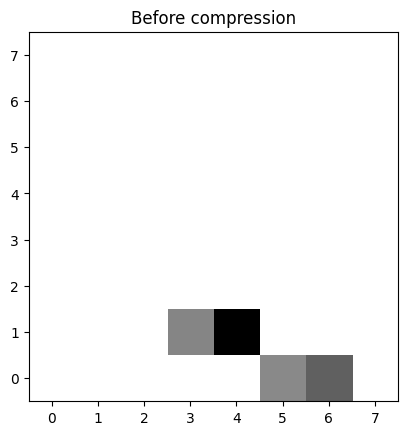

mu: mean=-0.0015, std=0.1695 | logvar: mean=-0.0548, std=0.3554
Loss statistics:
recon=127.5524, kl=369.1199, beta_kl=36.9120
After: (1, 8, 8)
After compression


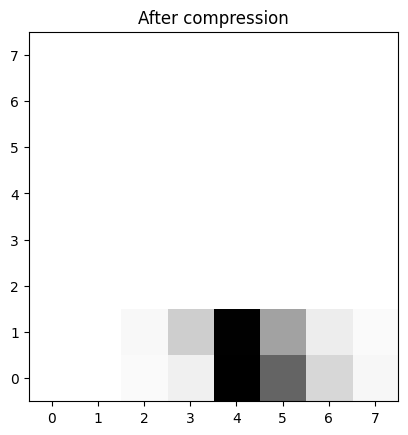

Epoch 82/120: 100%|██████████| 248/248 [00:00<00:00, 666.59it/s, Loss=159]


Epoch [82/120] Average Loss: 217.7179


Epoch 83/120: 100%|██████████| 248/248 [00:00<00:00, 610.28it/s, Loss=159]


Epoch [83/120] Average Loss: 218.3411


Epoch 84/120: 100%|██████████| 248/248 [00:00<00:00, 620.47it/s, Loss=200]


...

Epoch [89/120] Average Loss: 215.7840


Epoch 90/120: 100%|██████████| 248/248 [00:00<00:00, 585.78it/s, Loss=153]


Epoch [90/120] Average Loss: 216.7983


Epoch 91/120: 100%|██████████| 248/248 [00:00<00:00, 638.94it/s, Loss=157]


Epoch [91/120] Average Loss: 217.1849
Before compression
Before: (64, 8, 8)


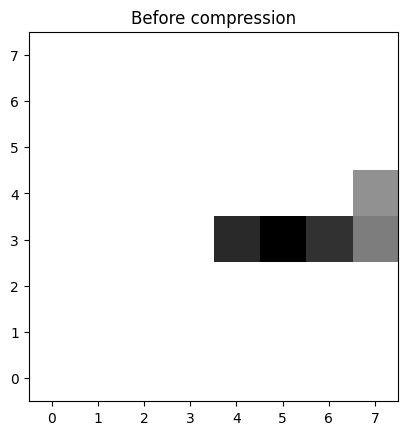

mu: mean=0.0021, std=0.1953 | logvar: mean=-0.0679, std=0.3988
Loss statistics:
recon=120.0872, kl=369.0712, beta_kl=36.9071
After: (1, 8, 8)
After compression


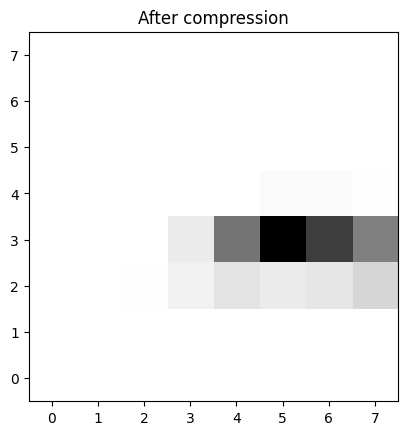

Epoch 92/120: 100%|██████████| 248/248 [00:00<00:00, 662.41it/s, Loss=159]


Epoch [92/120] Average Loss: 217.2603


Epoch 93/120: 100%|██████████| 248/248 [00:00<00:00, 651.97it/s, Loss=158]


Epoch [93/120] Average Loss: 215.0741


Epoch 94/120: 100%|██████████| 248/248 [00:00<00:00, 642.69it/s, Loss=155]


...

Epoch [99/120] Average Loss: 215.7362


Epoch 100/120: 100%|██████████| 248/248 [00:00<00:00, 626.53it/s, Loss=157]


Epoch [100/120] Average Loss: 215.9402


Epoch 101/120: 100%|██████████| 248/248 [00:00<00:00, 623.99it/s, Loss=153]


Epoch [101/120] Average Loss: 214.5998
Before compression
Before: (64, 8, 8)


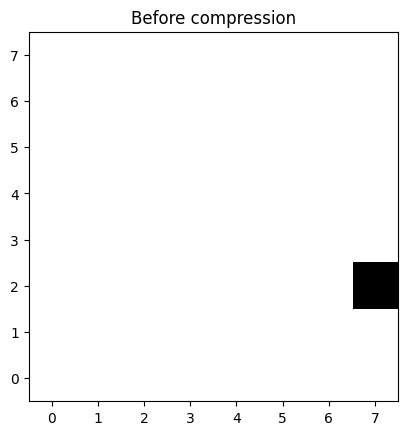

mu: mean=-0.0034, std=0.1610 | logvar: mean=-0.0593, std=0.3865
Loss statistics:
recon=115.5825, kl=374.1360, beta_kl=37.4136
After: (1, 8, 8)
After compression


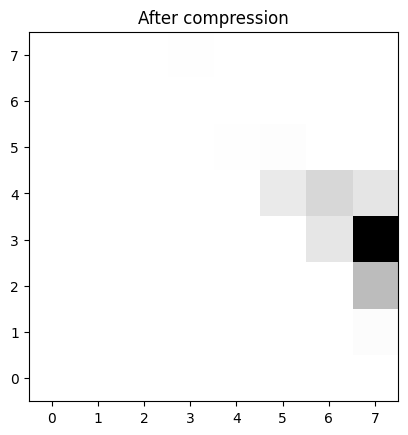

Epoch 102/120: 100%|██████████| 248/248 [00:00<00:00, 648.79it/s, Loss=156]


Epoch [102/120] Average Loss: 215.5298


Epoch 103/120: 100%|██████████| 248/248 [00:00<00:00, 660.79it/s, Loss=164]


Epoch [103/120] Average Loss: 215.6805


Epoch 104/120: 100%|██████████| 248/248 [00:00<00:00, 642.22it/s, Loss=158]


...

Epoch [109/120] Average Loss: 213.6249


Epoch 110/120: 100%|██████████| 248/248 [00:00<00:00, 642.19it/s, Loss=157]


Epoch [110/120] Average Loss: 214.6850


Epoch 111/120: 100%|██████████| 248/248 [00:00<00:00, 640.79it/s, Loss=154]


Epoch [111/120] Average Loss: 214.2422
Before compression
Before: (64, 8, 8)


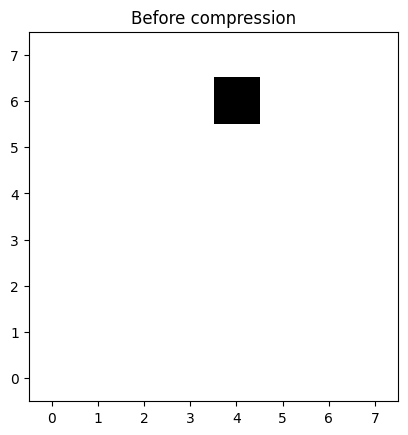

mu: mean=-0.0001, std=0.1583 | logvar: mean=-0.0574, std=0.3665
Loss statistics:
recon=116.9135, kl=375.0215, beta_kl=37.5021
After: (1, 8, 8)
After compression


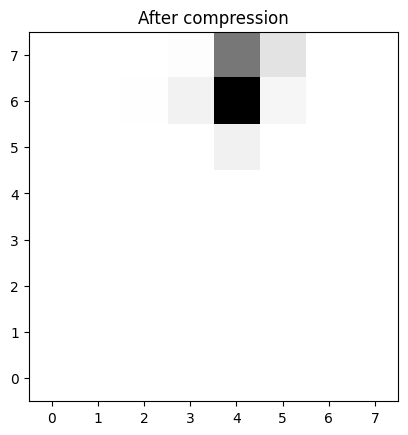

Epoch 112/120: 100%|██████████| 248/248 [00:00<00:00, 660.73it/s, Loss=158]


Epoch [112/120] Average Loss: 213.6825


Epoch 113/120: 100%|██████████| 248/248 [00:00<00:00, 665.07it/s, Loss=158]


Epoch [113/120] Average Loss: 214.7835


Epoch 114/120: 100%|██████████| 248/248 [00:00<00:00, 657.77it/s, Loss=159]


...

Epoch [118/120] Average Loss: 213.9520


Epoch 119/120: 100%|██████████| 248/248 [00:00<00:00, 641.29it/s, Loss=153]


Epoch [119/120] Average Loss: 212.9172


Epoch 120/120: 100%|██████████| 248/248 [00:00<00:00, 657.33it/s, Loss=155]

Epoch [120/120] Average Loss: 212.8020


In [35]:
average_loss = []
patches_before = []
patches_after = []

patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss.append(avg_loss)
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            patches_before.append(patch_test_ts[0])
            
            (
                recon_patch, 
                mu,
                logvar 
            ) = model(patch_test)
            
            print(
                f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
            )
            
            print("Loss statistics:")
            print(
                f"recon={recon_loss.item():.4f}, "
                f"kl={kl_loss.item():.4f}, "
                f"beta_kl={(beta * kl_loss).item():.4f}"
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
            
            patches_after.append(recon_patch_np[0])
        

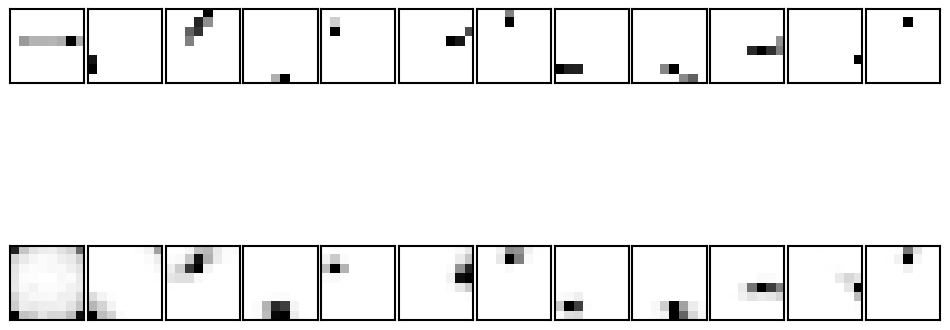

In [36]:
image_rows = [
    patches_before,
    patches_after
]
cols = len(image_rows[0])
rows = len(image_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(image_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [37]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.9250214695930481
encoder.0.bias 3.5574135780334473
encoder.2.weight 1.3890953063964844
encoder.2.bias 1.4035470485687256
encoder.4.weight 1.6303406953811646
encoder.4.bias 0.9366695880889893
fc_mean.weight 0.7989448308944702
fc_mean.bias 0.46595343947410583
fc_log_var.weight 0.22821122407913208
fc_log_var.bias 0.11580068618059158
decoder.0.weight 1.5859025716781616
decoder.0.bias 0.12241356819868088
decoder.2.weight 0.44614672660827637
decoder.2.bias 0.016727276146411896
decoder.4.weight 0.635549008846283
decoder.4.bias 0.00391619885340333


/tmp/ipykernel_2940260/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


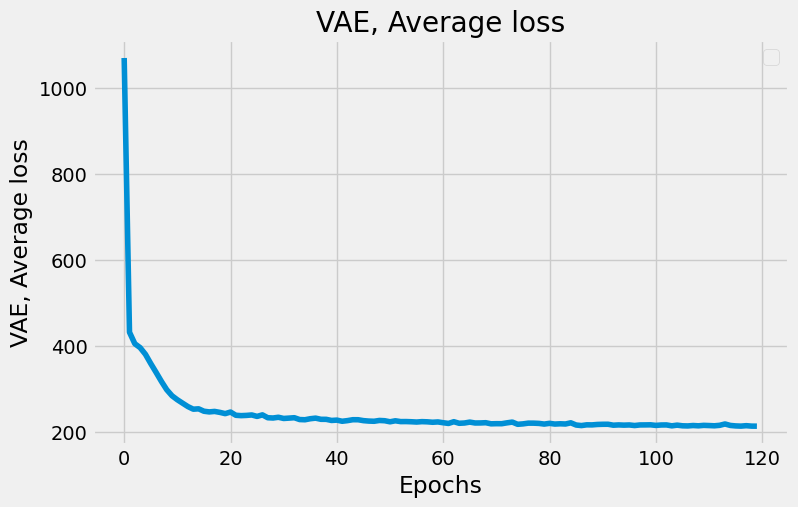

In [38]:
# display loss values
plot_metric_results(
    y_values=average_loss, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [39]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")